# Results — does prioritising by value beat prioritising by risk alone?

One business question, one comparison. Three ways of spending the same
retention budget, swept from 1k to 80k EUR at a **flat 20 EUR per action**:

| Line | Criterion |
|---|---|
| At random | none — the comparison floor |
| By churn risk | highest `p` first, the standard industry practice |
| By risk x value | highest `p * MonthlyCharges` first, what this project proposes |

The knapsack optimum is deliberately **not** on these charts. With a flat
cost the budget just buys a fixed number of slots, so the optimum is the
top-k of the risk-x-value ranking and its line would sit exactly on top of
it, hiding the comparison instead of adding to it. The knapsack earns its
place in the next step, where the cost per customer stops being constant.

Valuation is identical across the three lines (`expected_value`, H=12,
d=0.01, effectiveness=0.3): only the selection criterion differs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

from retention_optimizer.evaluation.figures import (
    plot_efficiency_curve,
    plot_value_curve,
)
from retention_optimizer.evaluation.strategies import (
    strategy_by_churn,
    strategy_by_priority,
    strategy_random,
)
from retention_optimizer.evaluation.sweep import load_oof, sweep_strategies

FIGURES_PATH = '../reports/figures/'
HIGHLIGHTS = [5000, 10000, 20000]  # budgets called out on the charts

# Valuation assumptions, declared once. MF becomes a slider in the S5 dashboard,
# so nothing downstream may hardcode it -- every sweep and every figure title
# reads it from here.
MF = 0.35       # EBITDA margin, the headline assumption
EFF = 0.3       # assumed retention effectiveness
H, D = 12, 0.01

# Business-readable names: the charts are read by people who do not know
# what `by_priority` refers to.
LABELS = {
    'random': 'At random',
    'by_churn': 'By churn risk',
    'by_priority': 'By risk \u00d7 value',
}
COLORS = {
    'random': '#898781',
    'by_churn': '#2a78d6',
    'by_priority': '#eb6834',
}

In [2]:
p, m, ids = load_oof('../data/processed/oof_predictions.csv')

budgets = np.arange(1000, 80001, 1000)
strategies = {
    'random': strategy_random,
    'by_churn': strategy_by_churn,
    'by_priority': strategy_by_priority,
}

df = sweep_strategies(p, m, budgets, strategies, cost=20.0, n_seeds=30,
                      margin_factor=MF)

print(f'{len(p)} customers | {len(budgets)} budgets | {len(df)} rows')
print('"At random" is the mean over 30 seeds (0..29) at every budget.')
df.head()

7043 customers | 80 budgets | 240 rows
"At random" is the mean over 30 seeds (0..29) at every budget.


,budget,strategy,expected_value,spend,n_selected
0,1000.0,random,1142.601455,1000.0,50
1,1000.0,by_churn,4285.748101,1000.0,50
2,1000.0,by_priority,4864.000190,1000.0,50
3,2000.0,random,2316.872097,2000.0,100
4,2000.0,by_churn,8379.194577,2000.0,100


## Figure A — value retained

How many euros of expected margin each way of spending recovers.

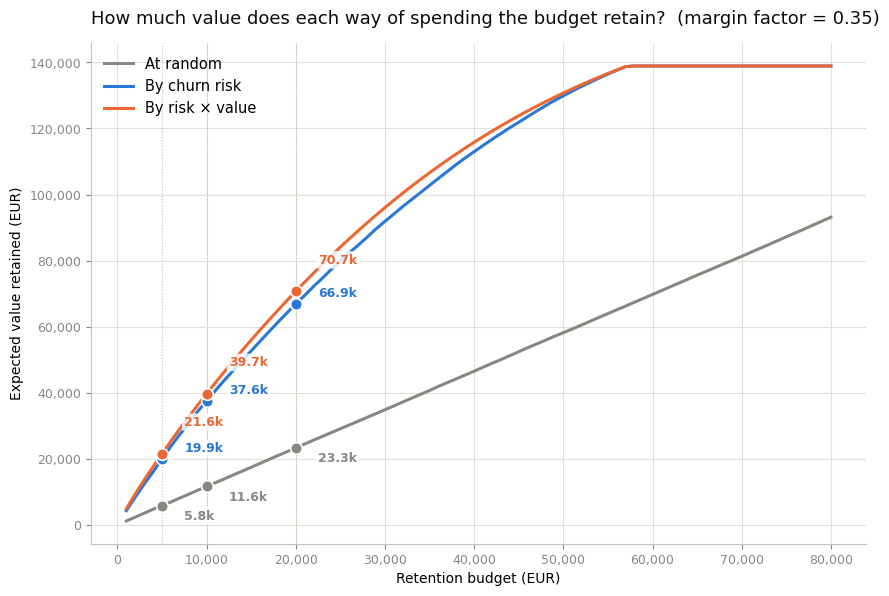

In [3]:
def style_money_axes(ax, ylabel, yfmt='{x:,.0f}'):
    """Thousands separators, recessive grid, no top/right spines.

    Kept here for the diagnostic and horizon charts further down, which are
    one-off and stay inline. The two headline figures go through
    `evaluation.figures`, which carries its own copy of this styling.
    """
    ax.set_xlabel('Retention budget (EUR)')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter(yfmt))
    ax.grid(color='#e1e0d9', linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('#c3c2b7')
    ax.tick_params(colors='#898781', labelsize=9)


plot_value_curve(
    df, MF, LABELS,
    budget_markers=HIGHLIGHTS,
    savepath=FIGURES_PATH + 'value_vs_budget_flatcost.png',
)
plt.show()

## Figure B — efficiency

Euros retained per euro spent. Absolute value always rises with the budget;
efficiency shows what each extra euro actually buys, and it is the axis on
which the three criteria separate most clearly at small budgets.

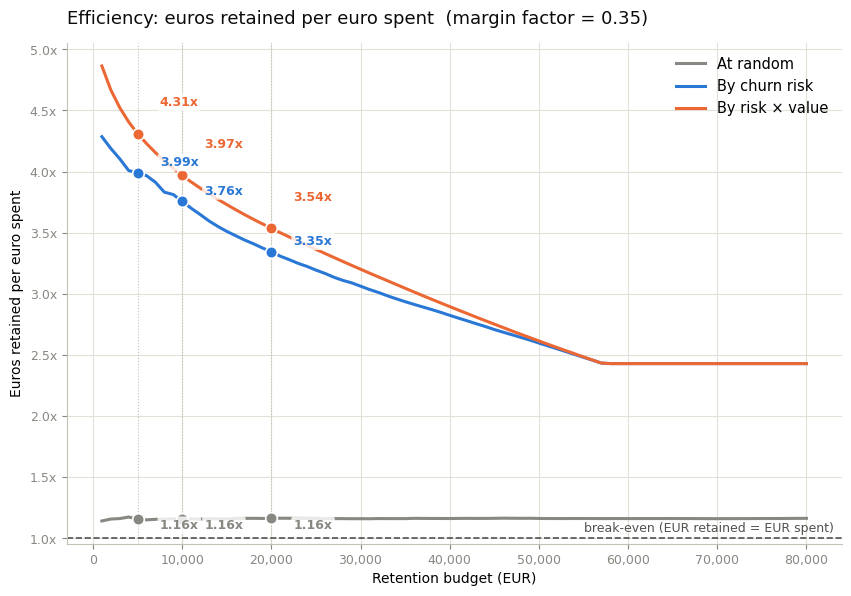

In [4]:
plot_efficiency_curve(
    df, MF, LABELS,
    budget_markers=HIGHLIGHTS,
    savepath=FIGURES_PATH + 'efficiency_vs_budget_flatcost.png',
)
plt.show()

## The headline number

What weighting the churn risk by customer value is worth, in euros, against
the industry-standard baseline of targeting by risk alone.

In [5]:
pivot = (
    df[df.budget.isin(HIGHLIGHTS)]
    .pivot(index='budget', columns='strategy', values='expected_value')
)

# Percentages are taken on NET value (expected revenue minus the budget
# actually spent), the same basis as the charts, the dashboard KPIs and the
# project's thesis. The euro delta is unaffected -- both strategies spend the
# same budget here -- but the denominator is smaller, so the percentage is
# larger than a gross-based one would be.
spend = (
    df[df.budget.isin(HIGHLIGHTS)]
    .pivot(index='budget', columns='strategy', values='spend')
)
net = pivot - spend

pivot['delta_eur'] = net.by_priority - net.by_churn
pivot['delta_pct_net'] = pivot.delta_eur / net.by_churn * 100

pivot = pivot.rename(columns=LABELS)[
    [LABELS['random'], LABELS['by_churn'], LABELS['by_priority'],
     'delta_eur', 'delta_pct_net']
]

print('Expected value retained, by budget and criterion (EUR)')
print('delta = "By risk \u00d7 value" minus "By churn risk"')
print('delta_pct_net = delta / NET value of the baseline (revenue - spend)\n')
print(pivot.round(2).to_string())
pivot.round(2)

Expected value retained, by budget and criterion (EUR)
delta = "By risk × value" minus "By churn risk"
delta_pct_net = delta / NET value of the baseline (revenue - spend)

strategy  At random  By churn risk  By risk × value  delta_eur  delta_pct_net
budget                                                                       
5000.0      5793.92       19945.59         21554.91    1609.32          10.77
10000.0    11609.05       37564.38         39684.75    2120.37           7.69
20000.0    23280.53       66901.07         70725.84    3824.76           8.15


strategy,At random,By churn risk,By risk × value,delta_eur,delta_pct_net
budget,,,,,
5000.0,5793.92,19945.59,21554.91,1609.32,10.77
10000.0,11609.05,37564.38,39684.75,2120.37,7.69
20000.0,23280.53,66901.07,70725.84,3824.76,8.15


---

## Diagnostic — is the delta curve smooth?

Not a deliverable chart. The headline table reads the gap at three budgets only
(10.77% at 5k, 7.69% at 10k, 8.15% at 20k, all on **net** value — expected
revenue minus what was spent), and a gap that *falls* and then
*rises* again is either a real feature of the ranking or an artifact of picking
three points off a noisy curve. A fine sweep settles it.

Only the two deterministic strategies run here: neither `by_churn` nor
`by_priority` uses a seed, so nothing in this delta comes from randomness and
the random floor is irrelevant to the question.

In [6]:
budgets_fine = np.arange(2000, 40001, 500)  # 2k..40k, 77 points
strategies_fine = {
    'by_churn': strategy_by_churn,
    'by_priority': strategy_by_priority,
}

df_fine = sweep_strategies(p, m, budgets_fine, strategies_fine, cost=20.0,
                           margin_factor=MF)

wide = df_fine.pivot(index='budget', columns='strategy', values='expected_value')
spend_fine = df_fine.pivot(index='budget', columns='strategy', values='spend')
net_fine = wide - spend_fine

# Same NET basis as the headline table.
wide['delta_eur'] = net_fine.by_priority - net_fine.by_churn
wide['delta_pct'] = wide.delta_eur / net_fine.by_churn * 100

print(f'{len(wide)} budgets from {wide.index.min():,.0f} to {wide.index.max():,.0f} EUR\n')
print('  budget   delta_pct')
for b, v in wide['delta_pct'].items():
    print(f'{b:9,.0f}   {v:7.2f}')

77 budgets from 2,000 to 40,000 EUR

  budget   delta_pct
    2,000     15.02
    2,500     14.32
    3,000     13.48
    3,500     14.68
    4,000     13.21
    4,500     12.13
    5,000     10.77
    5,500     10.26
    6,000      8.86
    6,500      8.55
    7,000      8.33
    7,500      8.54
    8,000      9.04
    8,500      8.03
    9,000      7.60
    9,500      8.00
   10,000      7.69
   10,500      7.92
   11,000      7.96
   11,500      8.04
   12,000      8.15
   12,500      8.51
   13,000      8.55
   13,500      8.63
   14,000      8.71
   14,500      8.75
   15,000      8.73
   15,500      8.48
   16,000      8.59
   16,500      8.30
   17,000      8.51
   17,500      8.22
   18,000      8.30
   18,500      8.23
   19,000      8.30
   19,500      8.15
   20,000      8.15
   20,500      8.16
   21,000      8.32
   21,500      8.21
   22,000      8.15
   22,500      8.17
   23,000      8.09
   23,500      7.84
   24,000      7.79
   24,500      7.73
   25,000      7.73
  

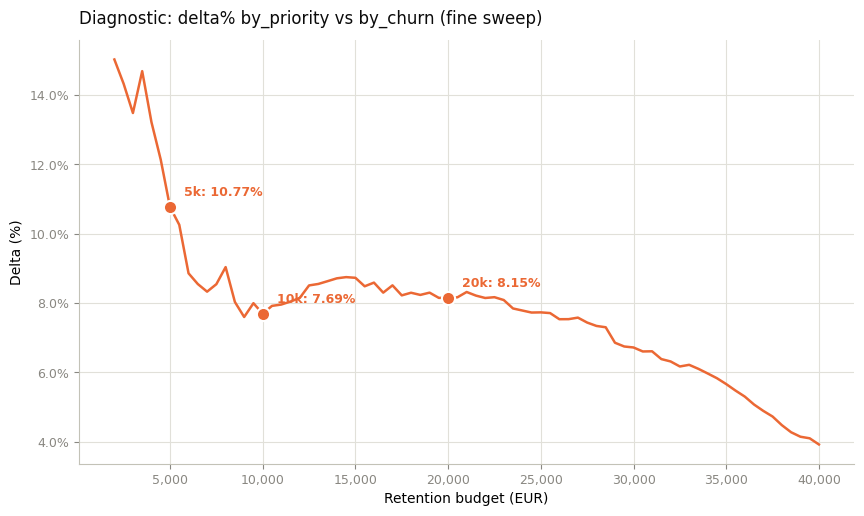

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(wide.index, wide.delta_pct, color=COLORS['by_priority'], linewidth=1.8,
        zorder=2)

marks = wide.loc[wide.index.isin(HIGHLIGHTS)]
ax.scatter(marks.index, marks.delta_pct, s=90, color=COLORS['by_priority'],
           edgecolor='white', linewidth=1.5, zorder=3)
for b, r in marks.iterrows():
    ax.annotate(f'{b/1000:,.0f}k: {r.delta_pct:.2f}%', xy=(b, r.delta_pct),
                xytext=(10, 8), textcoords='offset points', fontsize=9,
                fontweight='bold', color=COLORS['by_priority'])

style_money_axes(ax, 'Delta (%)', yfmt='{x:,.1f}%')
ax.set_title('Diagnostic: delta% by_priority vs by_churn (fine sweep)',
             fontsize=12, loc='left', pad=12, color='#0b0b0b')
plt.show()

In [8]:
d = wide['delta_pct']

print(f'MAX delta_pct : {d.max():.2f}%  at {d.idxmax():,.0f} EUR')
print(f'MIN delta_pct : {d.min():.2f}%  at {d.idxmin():,.0f} EUR')

steps = d.diff().dropna()
monotonic = bool((steps <= 0).all())
print(f'monotonically decreasing: {monotonic}')
print(f'  ({int((steps > 0).sum())} steps up, {int((steps < 0).sum())} steps down)')

if not monotonic:
    # Raw steps flip sign constantly at this resolution; smoothing over 5 points
    # (2,500 EUR) exposes the shape rather than the point-to-point jitter.
    smooth = d.rolling(5, center=True).mean().dropna()
    slope = np.sign(smooth.diff()).dropna()
    turns = slope.index[1:][slope.values[1:] != slope.values[:-1]]

    print('\napproximate turning points (5-point smoothed):')
    for b in turns:
        direction = 'trough -> rising' if slope.loc[b] > 0 else 'peak -> falling'
        print(f'  {b:9,.0f} EUR   {smooth.loc[b]:6.2f}%   {direction}')

MAX delta_pct : 15.02%  at 2,000 EUR
MIN delta_pct : 3.92%  at 40,000 EUR
monotonically decreasing: False
  (26 steps up, 50 steps down)

approximate turning points (5-point smoothed):
     10,500 EUR     7.92%   trough -> rising
     14,500 EUR     8.66%   peak -> falling
     20,000 EUR     8.22%   trough -> rising
     20,500 EUR     8.20%   peak -> falling
     21,500 EUR     8.20%   trough -> rising
     22,000 EUR     8.19%   peak -> falling


---

# Figure 2 — when contacting a customer does not cost the same for everyone

The first figure held the action cost flat at 20 EUR, and under a flat cost the
knapsack has nothing to decide: the budget buys a fixed number of slots and the
optimum *is* the top-k of the risk-x-value ranking. That is why the optimal
strategy was left off Figure 1.

Reaching customers does not cost the same in practice. A month-to-month customer
needs an expensive channel; someone locked into a two-year contract can be
handled by a cheap automated touch. Declaring that policy over the observable
`Contract` column turns the budget into a genuine packing problem, and the
second business question becomes answerable: **does optimising the allocation
add anything over simply ranking, once contact costs differ?**

All four strategies pay the same channel costs. Three absorb them naively — they
rank, then walk down the list until the next customer does not fit. Only the
knapsack optimises against the cost structure.

In [9]:
from retention_optimizer.evaluation.strategies import (
    channel_cost_from_contract,
    strategy_optimal,
)
from retention_optimizer.models.churn import load_data

# `Contract` is not in the OOF csv: it survives preprocess() but encode() turns
# it into dummies. Rebuild the S1 frame, which still carries customerID.
df_s1 = load_data('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
aligned = df_s1.set_index('customerID').reindex(ids)

# Alignment goes through customerID, never through position: the two frames are
# produced by different code paths and nothing guarantees a shared row order.
assert len(aligned) == len(ids), f'length mismatch: {len(aligned)} vs {len(ids)}'
assert aligned.index.equals(pd.Index(ids)), 'customerID order does not match ids'
missing = aligned['Contract'].isna()
assert not missing.any(), (
    f'{int(missing.sum())} customerIDs carry no Contract, first few: '
    f'{list(aligned.index[missing][:5])}'
)

cost_vector = channel_cost_from_contract(aligned['Contract'])

assert len(cost_vector) == 7043, f'expected 7043 costs, got {len(cost_vector)}'
assert set(np.unique(cost_vector)) <= {40.0, 15.0, 3.0}, 'unexpected cost values'

print('Alignment by customerID: OK (7043 rows, same order, no gaps)\n')
print('Channel cost distribution')
for contract, unit in [('Month-to-month', 40.0), ('One year', 15.0), ('Two year', 3.0)]:
    n = int((cost_vector == unit).sum())
    print(f'  {contract:<16} {unit:5,.0f} EUR   {n:5,} customers  ({n / len(cost_vector):6.1%})')
print(f'\n  mean cost per contact: {cost_vector.mean():.4f} EUR '
      f'(vs the flat 20 EUR of Figure 1)')

Alignment by customerID: OK (7043 rows, same order, no gaps)

Channel cost distribution
  Month-to-month      40 EUR   3,875 customers  ( 55.0%)
  One year            15 EUR   1,473 customers  ( 20.9%)
  Two year             3 EUR   1,695 customers  ( 24.1%)

  mean cost per contact: 25.8668 EUR (vs the flat 20 EUR of Figure 1)


In [10]:
# Slow cell: the knapsack solves one MILP with 7,043 binaries per budget.
strategies_het = {
    'random': strategy_random,
    'by_churn': strategy_by_churn,
    'by_priority': strategy_by_priority,
    'optimal': strategy_optimal,
}

df_het = sweep_strategies(p, m, budgets, strategies_het, cost=cost_vector,
                          n_seeds=30, margin_factor=MF)

print(f'{len(df_het)} rows | {len(budgets)} budgets x {len(strategies_het)} strategies')
df_het.head()

320 rows | 80 budgets x 4 strategies


,budget,strategy,expected_value,spend,n_selected
0,1000.0,random,896.395081,994.0,36
1,1000.0,by_churn,2260.755994,1000.0,25
2,1000.0,by_priority,2510.682103,1000.0,25
3,1000.0,optimal,3910.818190,999.0,237
4,2000.0,random,1803.298414,1974.0,80


## Figure 2 — value retained under channel costs

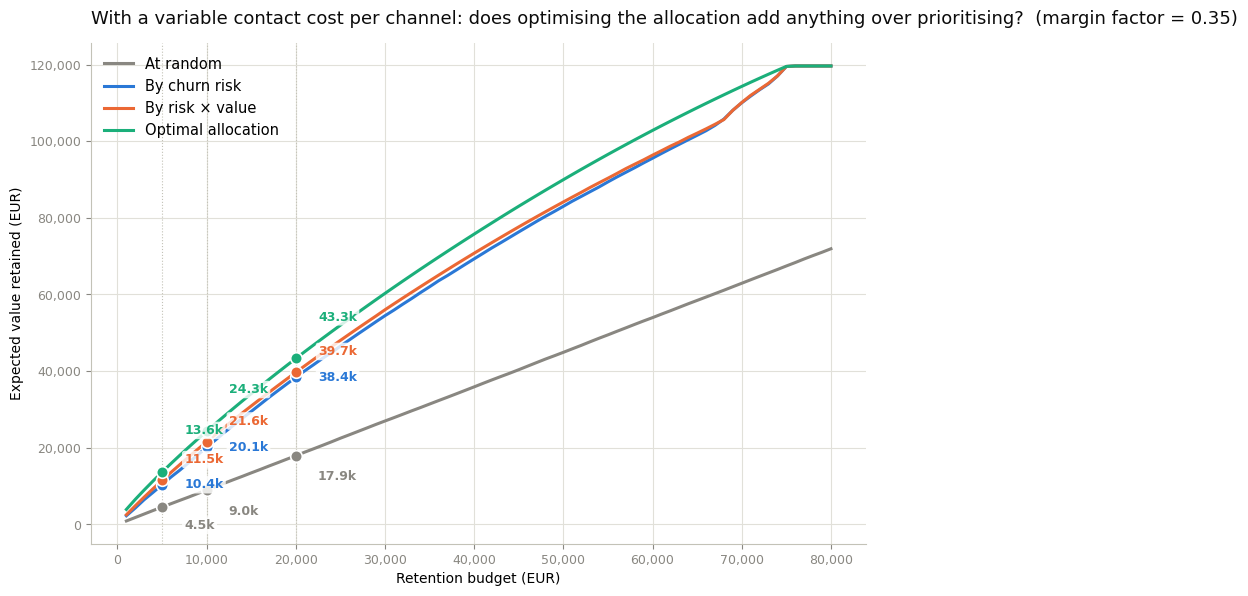

In [11]:
LABELS_HET = {
    'random': 'At random',
    'by_churn': 'By churn risk',
    'by_priority': 'By risk \u00d7 value',
    'optimal': 'Optimal allocation',
}
COLORS_HET = {**COLORS, 'optimal': '#1baf7a'}

plot_value_curve(
    df_het, MF, LABELS_HET,
    budget_markers=HIGHLIGHTS,
    title='With a variable contact cost per channel: does optimising the '
          'allocation add anything over prioritising?',
    savepath=FIGURES_PATH + 'value_vs_budget_channelcost.png',
)
plt.show()

### Efficiency under channel costs

The chart the flat-cost section had but this one was missing. The break-even
line matters here in a way it did not before: under channel costs some ways of
spending fall below it.

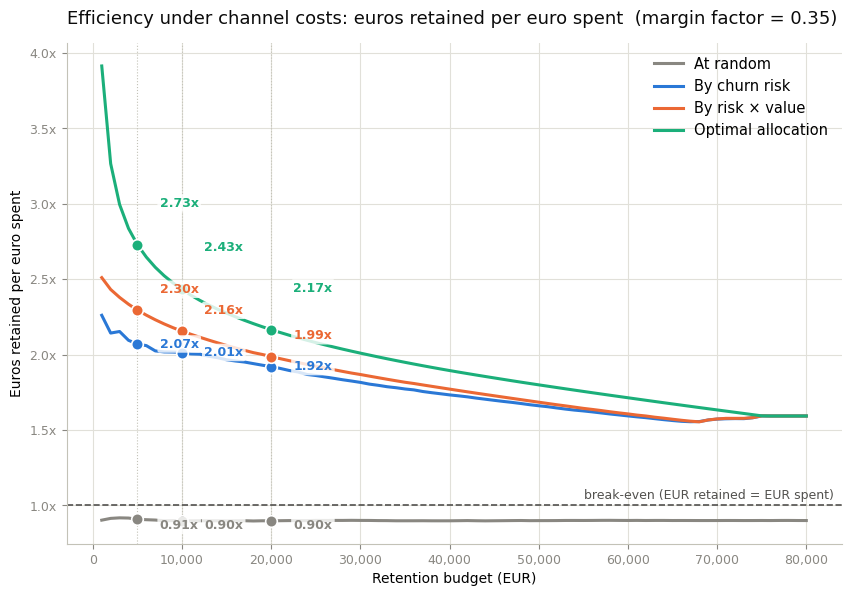

In [12]:
plot_efficiency_curve(
    df_het, MF, LABELS_HET,
    budget_markers=HIGHLIGHTS,
    title='Efficiency under channel costs: euros retained per euro spent',
    savepath=FIGURES_PATH + 'efficiency_vs_budget_channelcost.png',
)
plt.show()

## The two deltas

`delta_value` is what weighting risk by customer value buys over the industry
baseline. `delta_optim` is what optimising the packing buys **on top of that** —
the part attributable to the solver rather than to the ranking.

In [13]:
pivot_het = (
    df_het[df_het.budget.isin(HIGHLIGHTS)]
    .pivot(index='budget', columns='strategy', values='expected_value')
)

# NET basis, as in the flat table. Under channel costs the strategies do not
# all spend exactly the same amount, so here the net delta differs slightly
# from the gross one rather than only changing the denominator.
spend_het = (
    df_het[df_het.budget.isin(HIGHLIGHTS)]
    .pivot(index='budget', columns='strategy', values='spend')
)
net_het = pivot_het - spend_het

pivot_het['delta_value'] = net_het.by_priority - net_het.by_churn
pivot_het['delta_value_pct_net'] = pivot_het.delta_value / net_het.by_churn * 100
pivot_het['delta_optim'] = net_het.optimal - net_het.by_priority
pivot_het['delta_optim_pct_net'] = (
    pivot_het.delta_optim / net_het.by_priority * 100
)

pivot_het = pivot_het[
    ['random', 'by_churn', 'by_priority', 'optimal',
     'delta_value', 'delta_value_pct_net', 'delta_optim', 'delta_optim_pct_net']
]

print('Expected value retained under channel costs (EUR)')
print('delta_value = by_priority - by_churn   |   delta_optim = optimal - by_priority')
print('percentages on NET value (revenue - spend)\n')
print(pivot_het.round(2).to_string())
pivot_het.round(2)

Expected value retained under channel costs (EUR)
delta_value = by_priority - by_churn   |   delta_optim = optimal - by_priority
percentages on NET value (revenue - spend)

strategy    random  by_churn  by_priority   optimal  delta_value  delta_value_pct_net  delta_optim  delta_optim_pct_net
budget                                                                                                                 
5000.0     4529.27  10351.93     11476.24  13645.67      1124.31                21.01      2169.43                33.50
10000.0    8955.81  20139.09     21554.91  24320.94      1415.83                13.96      2767.03                23.95
20000.0   17921.90  38404.41     39684.75  43304.19      1305.34                 7.09      3595.44                18.24


strategy,random,by_churn,by_priority,optimal,delta_value,delta_value_pct_net,delta_optim,delta_optim_pct_net
budget,,,,,,,,
5000.0,4529.27,10351.93,11476.24,13645.67,1124.31,21.01,2169.43,33.50
10000.0,8955.81,20139.09,21554.91,24320.94,1415.83,13.96,2767.03,23.95
20000.0,17921.90,38404.41,39684.75,43304.19,1305.34,7.09,3595.44,18.24


## What each strategy actually bought at 10k

With heterogeneous costs "spending 10,000 EUR" no longer means the same number of
customers for everyone: a strategy that leans on cheap two-year contacts reaches
more people for the same money. Shown explicitly so the comparison cannot be
mistaken for the optimum winning merely by treating a larger crowd.

In [14]:
detail = (
    df_het[df_het.budget == 10000]
    .set_index('strategy')[['expected_value', 'spend', 'n_selected']]
)
detail['eur_per_customer'] = detail.spend / detail.n_selected
detail['value_per_customer'] = detail.expected_value / detail.n_selected
detail.index = [LABELS_HET[k] for k in detail.index]

print('Budget = 10,000 EUR, channel costs\n')
print(detail.round(2).to_string())
detail.round(2)

Budget = 10,000 EUR, channel costs

                    expected_value    spend  n_selected  eur_per_customer  value_per_customer
At random                  8955.81   9985.0         377             26.49               23.76
By churn risk             20139.09  10000.0         250             40.00               80.56
By risk × value           21554.91  10000.0         250             40.00               86.22
Optimal allocation        24320.94   9999.0         643             15.55               37.82


,expected_value,spend,n_selected,eur_per_customer,value_per_customer
At random,8955.81,9985.0,377,26.49,23.76
By churn risk,20139.09,10000.0,250,40.00,80.56
By risk × value,21554.91,10000.0,250,40.00,86.22
Optimal allocation,24320.94,9999.0,643,15.55,37.82


---

# [ASSUMPTION] Sensitivity analysis — not a result

**Nothing in this section is a measurement.** Everything above assumes
`effectiveness = 0.3` for every customer: acting on anyone saves 30% of the
churn we predicted for them. This section probes what happens if that
assumption is wrong for one segment, and reports a **bound, not an estimate**.

**Why this segment.** At a 10,000 EUR budget the knapsack selects 643 customers,
and 333 of them — 51.8% — hold two-year contracts. They are cheap to reach
(999 EUR, 10% of the budget) and they carry 15% of the claimed value, at 10.4x
return per euro against 6.6x for the rest. The solver is not misbehaving: it
picks the high-risk tail of that segment (mean p of 0.0875 against 0.0335 for
all two-year customers) and touches only 19.6% of it.

**Why it is questionable anyway.** Those customers are contractually locked for
up to two years. A uniform 30% effectiveness credits a retention action on them
with the same power as on a month-to-month customer who can leave next week.
That is hard to defend, and no data in this project measures it.

**What the scenario below is.** Setting `effectiveness = 0` for two-year
customers is a deliberate **extreme lower bound**: it asserts the action does
absolutely nothing for them. The true value is somewhere between 0 and 0.3 and
nothing here identifies where. The scenario exists to answer one question —
*how much of the optimizer's advantage survives if this segment is worthless?* —
not to claim the answer is zero.

Both the current figure and the bound use the identical valuation formula, so
the two columns are directly comparable.

In [15]:
is_two_year = (aligned['Contract'] == 'Two year').to_numpy()

# Extreme bound, not an estimate: the action is assumed to do nothing at all for
# contractually locked customers, while staying at 0.3 for everyone else.
eff_bound = np.where(is_two_year, 0.0, 0.3)

rows = []
for b in HIGHLIGHTS:
    _, base_opt = strategy_optimal(p, m, b, cost=cost_vector, margin_factor=MF)
    _, base_pri = strategy_by_priority(p, m, b, cost=cost_vector, margin_factor=MF)
    _, bound_opt = strategy_optimal(p, m, b, cost=cost_vector, effectiveness=eff_bound,
                                 margin_factor=MF)
    _, bound_pri = strategy_by_priority(p, m, b, cost=cost_vector,
                                        effectiveness=eff_bound,
                                        margin_factor=MF)

    # NET basis throughout, matching the tables above.
    def net(info):
        return info['expected_value'] - info['spend']

    base_delta = net(base_opt) - net(base_pri)
    bound_delta = net(bound_opt) - net(bound_pri)

    rows.append({
        'budget': b,
        'delta_optim_as_reported': base_delta,
        'pct_as_reported_net': base_delta / net(base_pri) * 100,
        'delta_optim_lower_bound': bound_delta,
        'pct_lower_bound_net': bound_delta / net(bound_pri) * 100,
        'share_surviving_pct': bound_delta / base_delta * 100,
    })

sensitivity = pd.DataFrame(rows).set_index('budget')

print('[ASSUMPTION] Sensitivity of the optimiser advantage to two-year effectiveness')
print('as_reported  : effectiveness = 0.3 for everyone (the figures above)')
print('lower_bound  : effectiveness = 0.0 for two-year customers (extreme scenario)\n')
print(sensitivity.round(2).to_string())
print('\nThe advantage shrinks but never reverses: the knapsack still beats the')
print('ranking under the most hostile assumption available. Where the truth sits')
print('between the two columns is not measured here.')
sensitivity.round(2)

[ASSUMPTION] Sensitivity of the optimiser advantage to two-year effectiveness
as_reported  : effectiveness = 0.3 for everyone (the figures above)
lower_bound  : effectiveness = 0.0 for two-year customers (extreme scenario)

        delta_optim_as_reported  pct_as_reported_net  delta_optim_lower_bound  pct_lower_bound_net  share_surviving_pct
budget                                                                                                                 
5000                    2169.43                33.50                   746.81                11.53                34.42
10000                   2767.03                23.95                  1130.76                 9.79                40.87
20000                   3595.44                18.24                  1708.44                 8.67                47.52

The advantage shrinks but never reverses: the knapsack still beats the
ranking under the most hostile assumption available. Where the truth sits
between the two columns is not

,delta_optim_as_reported,pct_as_reported_net,delta_optim_lower_bound,pct_lower_bound_net,share_surviving_pct
budget,,,,,
5000,2169.43,33.50,746.81,11.53,34.42
10000,2767.03,23.95,1130.76,9.79,40.87
20000,3595.44,18.24,1708.44,8.67,47.52


---

# Business translation — euros a CFO would sign off on

Everything above ran with `margin_factor = 1.0`, i.e. treating revenue as if it
were all margin. That is fine for the **figures**, which compare strategies
against each other: the margin factor is a constant multiplier, so it moves
every line by the same amount and the shape of the comparison is invariant to
it. It is not fine for quoting a euro number.

From here on the tables use **`margin_factor = 0.35`**, a defensible EBITDA
margin for a telco. Figures show *shape* at mf=1.0, business tables show *level*
at mf=0.35 — a declared split, not an inconsistency. The mf=1.0 ROI appears
exactly once below, labelled as a theoretical upper bound, and is never the
headline.

## Where the ROI actually comes from

`ROI = [eff x mf x A(H,d)]  x  [sum(p x m over selected) / spend]`

The first bracket is a **valuation scalar we choose**: effectiveness, margin
factor and the annuity horizon are all assumptions. The second is the only part
the model earns — how good the selected customers are per euro spent.

In [16]:
from retention_optimizer.optimization.value import annuity_factor, expected_value

# MF / EFF / H / D are declared once at the top of the notebook.
# The ROI is dominated by the valuation scalar, which we set with assumptions --
# not by the optimiser's merit: quadrupling the margin factor quadruples the
# headline ROI without a single customer changing hands.
roi_mask, _ = strategy_by_priority(p, m, 10000.0, cost=20.0, margin_factor=MF)

selection_quality = (p * m)[roi_mask].sum() / (20.0 * roi_mask.sum())
annuity = annuity_factor(H, D)

roi_rows = []
for mf, label in [(MF, f'Headline (margin factor = {MF})'),
                  (1.0, 'UPPER BOUND (margin = revenue, unrealistic)')]:
    scalar = EFF * mf * annuity
    roi_rows.append({
        'scenario': label,
        'valuation_scalar': scalar,
        'selection_quality': selection_quality,
        'roi': scalar * selection_quality,
    })

roi_table = pd.DataFrame(roi_rows).set_index('scenario')

print(f'by_priority, flat cost 20 EUR, budget 10,000 EUR, H={H}, d={D}\n')
print(f'  annuity factor A({H}, {D})        : {annuity:.4f}')
print(f'  selection quality sum(p*m)/spend : {selection_quality:.4f}   <- earned by the model')
print(f'  valuation scalar eff x mf x A    : assumption-driven\n')
print(roi_table.round(4).to_string())
print(f'\nThe scalar moves the ROI from {roi_rows[0]["roi"]:.2f}x to '
      f'{roi_rows[1]["roi"]:.2f}x with an identical customer list.')
roi_table.round(4)

by_priority, flat cost 20 EUR, budget 10,000 EUR, H=12, d=0.01

  annuity factor A(12, 0.01)        : 11.2551
  selection quality sum(p*m)/spend : 3.3580   <- earned by the model
  valuation scalar eff x mf x A    : assumption-driven

                                             valuation_scalar  selection_quality      roi
scenario                                                                                 
Headline (margin factor = 0.35)                        1.1818              3.358   3.9685
UPPER BOUND (margin = revenue, unrealistic)            3.3765              3.358  11.3385

The scalar moves the ROI from 3.97x to 11.34x with an identical customer list.


,valuation_scalar,selection_quality,roi
scenario,,,
Headline (margin factor = 0.35),1.1818,3.358,3.9685
"UPPER BOUND (margin = revenue, unrealistic)",3.3765,3.358,11.3385


## CFO panels — targeted spending vs treating everyone

One panel per cost regime, each with its own **"Everyone (no limit)"** row:
contacting all 7,043 customers with no budget constraint. Same customers and
same retained value in both panels; only the bill changes.

In [17]:
CFO_BUDGETS = [5000.0, 10000.0, 20000.0]
CFO_LABELS = {
    'random': 'At random',
    'by_churn': 'By churn risk',
    'by_priority': 'By risk \u00d7 value',
    'optimal': 'Optimal allocation',
    'everyone': 'Everyone (no limit)',
}

value_everyone = float(expected_value(p, m, EFF, MF, H, D).sum())


def cfo_panel(sweep_df, spend_everyone):
    """Assemble one panel: strategies at each budget plus the everyone row."""
    rows = []
    for _, r in sweep_df.iterrows():
        rows.append({
            'strategy': CFO_LABELS[r.strategy],
            'budget': f'{r.budget:,.0f}',
            'value_retained': r.expected_value,
            'spend': r.spend,
            'efficiency': r.expected_value / r.spend,
            'n_selected': int(r.n_selected),
        })
    rows.append({
        'strategy': CFO_LABELS['everyone'],
        'budget': 'no limit',
        'value_retained': value_everyone,
        'spend': spend_everyone,
        'efficiency': value_everyone / spend_everyone,
        'n_selected': len(p),
    })
    return pd.DataFrame(rows).set_index(['budget', 'strategy'])


def cfo_reading(panel, targeted_label, spend_everyone):
    """One-line comparison of the 10k targeted run against treating everyone."""
    t = panel.loc[('10,000', targeted_label)]
    return (
        f'{targeted_label} at 10,000 EUR recovers '
        f'{t.value_retained / value_everyone:.1%} of the mass-programme value '
        f'while spending {t.spend / spend_everyone:.1%} of its budget '
        f'-- {t.efficiency / (value_everyone / spend_everyone):.2f}x the efficiency.'
    )

### Panel 1 — flat cost (20 EUR per action), accompanies Figure 1

In [18]:
SPEND_EVERYONE_FLAT = len(p) * 20.0

sweep_flat_cfo = sweep_strategies(
    p, m, CFO_BUDGETS,
    {'random': strategy_random, 'by_churn': strategy_by_churn,
     'by_priority': strategy_by_priority},
    cost=20.0, margin_factor=MF,
)
panel_flat = cfo_panel(sweep_flat_cfo, SPEND_EVERYONE_FLAT)

print(f'PANEL 1 -- flat cost, margin factor {MF}\n')
print(panel_flat.round(2).to_string())
print('\nCFO reading:')
print(' ', cfo_reading(panel_flat, CFO_LABELS['by_priority'], SPEND_EVERYONE_FLAT))
panel_flat.round(2)

PANEL 1 -- flat cost, margin factor 0.35

                              value_retained     spend  efficiency  n_selected
budget   strategy                                                             
5,000    At random                   5793.92    5000.0        1.16         250
         By churn risk              19945.59    5000.0        3.99         250
         By risk × value            21554.91    5000.0        4.31         250
10,000   At random                  11609.05   10000.0        1.16         500
         By churn risk              37564.38   10000.0        3.76         500
         By risk × value            39684.75   10000.0        3.97         500
20,000   At random                  23280.53   20000.0        1.16        1000
         By churn risk              66901.07   20000.0        3.35        1000
         By risk × value            70725.84   20000.0        3.54        1000
no limit Everyone (no limit)       163779.84  140860.0        1.16        7043

CFO readi

value_retained     spend  efficiency  n_selected
budget   strategy                                                             
5,000    At random                   5793.92    5000.0        1.16         250
         By churn risk              19945.59    5000.0        3.99         250
         By risk × value            21554.91    5000.0        4.31         250
10,000   At random                  11609.05   10000.0        1.16         500
         By churn risk              37564.38   10000.0        3.76         500
         By risk × value            39684.75   10000.0        3.97         500
20,000   At random                  23280.53   20000.0        1.16        1000
         By churn risk              66901.07   20000.0        3.35        1000
         By risk × value            70725.84   20000.0        3.54        1000
no limit Everyone (no limit)       163779.84  140860.0        1.16        7043

### Panel 2 — channel cost, accompanies Figure 2

In [19]:
# Same alignment guard as the Figure 2 section: never trust row order.
aligned_cfo = df_s1.set_index('customerID').reindex(ids)
assert len(aligned_cfo) == len(ids), 'length mismatch after reindex'
assert aligned_cfo.index.equals(pd.Index(ids)), 'customerID order does not match ids'
assert not aligned_cfo['Contract'].isna().any(), 'customerIDs without Contract'

cost_vector_cfo = channel_cost_from_contract(aligned_cfo['Contract'])
assert np.array_equal(cost_vector_cfo, cost_vector), 'cost vector differs from Figure 2'

SPEND_EVERYONE_CHANNEL = float(cost_vector_cfo.sum())

sweep_channel_cfo = sweep_strategies(
    p, m, CFO_BUDGETS,
    {'random': strategy_random, 'by_churn': strategy_by_churn,
     'by_priority': strategy_by_priority, 'optimal': strategy_optimal},
    cost=cost_vector_cfo, margin_factor=MF,
)
panel_channel = cfo_panel(sweep_channel_cfo, SPEND_EVERYONE_CHANNEL)

print(f'PANEL 2 -- channel cost, margin factor {MF}')
print(f'Treating everyone now costs {SPEND_EVERYONE_CHANNEL:,.0f} EUR '
      f'(vs {SPEND_EVERYONE_FLAT:,.0f} flat): the mass programme has to pay the '
      f'expensive channel for every month-to-month customer.\n')
print(panel_channel.round(2).to_string())
print('\nCFO reading:')
print(' ', cfo_reading(panel_channel, CFO_LABELS['optimal'], SPEND_EVERYONE_CHANNEL))
print(f'\n  Note: at {panel_channel.loc[("no limit", CFO_LABELS["everyone"]), "efficiency"]:.3f}x '
      'the mass programme returns less than it costs -- it destroys value.')
panel_channel.round(2)

PANEL 2 -- channel cost, margin factor 0.35
Treating everyone now costs 182,180 EUR (vs 140,860 flat): the mass programme has to pay the expensive channel for every month-to-month customer.

                              value_retained     spend  efficiency  n_selected
budget   strategy                                                             
5,000    At random                   4529.27    4991.0        0.91         192
         By churn risk              10351.93    5000.0        2.07         125
         By risk × value            11476.24    5000.0        2.30         125
         Optimal allocation         13645.67    5000.0        2.73         461
10,000   At random                   8955.81    9985.0        0.90         377
         By churn risk              20139.09   10000.0        2.01         250
         By risk × value            21554.91   10000.0        2.16         250
         Optimal allocation         24320.94    9999.0        2.43         643
20,000   At random 

value_retained     spend  efficiency  n_selected
budget   strategy                                                             
5,000    At random                   4529.27    4991.0        0.91         192
         By churn risk              10351.93    5000.0        2.07         125
         By risk × value            11476.24    5000.0        2.30         125
         Optimal allocation         13645.67    5000.0        2.73         461
10,000   At random                   8955.81    9985.0        0.90         377
         By churn risk              20139.09   10000.0        2.01         250
         By risk × value            21554.91   10000.0        2.16         250
         Optimal allocation         24320.94    9999.0        2.43         643
20,000   At random                  17921.90   19977.0        0.90         765
         By churn risk              38404.41   20000.0        1.92         500
         By risk × value            39684.75   19975.0        1.99         500
         Optimal allocation         43304.19   19999.0        2.17         956
no limit Everyone (no limit)       163779.84  182180.0        0.90        7043

---

# Horizon sensitivity — H moves the level, not the selection

How many months of retained margin we count (`H`) is an assumption like the
margin factor, and it changes every euro figure in this notebook. The question
is whether it changes any *decision*.

It does not, below a threshold. `H` enters `expected_value` only through the
annuity factor `A(H, d)`, a constant that multiplies every customer alike — so
it rescales value without touching the `p x m` ordering. It only starts to
matter when a shorter horizon drags customers below the cost threshold and they
stop being worth acting on at all.

Everything here uses `by_priority`, flat cost 20 EUR, `mf=0.35`, `eff=0.3`,
`d=0.01` — the clean case. The interaction with heterogeneous cost is discussed
at the end rather than recomputed.

## A) Selection invariance

In [20]:
HORIZONS = [6, 12, 24]
H_LABELS = {6: 'H = 6 months', 12: 'H = 12 months (base case)', 24: 'H = 24 months'}
H_COLORS = {6: '#eb6834', 12: '#2a78d6', 24: '#1baf7a'}

masks_by_h = {
    h: strategy_by_priority(p, m, 10000.0, cost=20.0, margin_factor=MF, H=h)[0]
    for h in HORIZONS
}

identical = all(
    np.array_equal(masks_by_h[HORIZONS[0]], masks_by_h[h]) for h in HORIZONS[1:]
)
assert identical, 'selection changed with H below the elbow -- the claim is broken'

print(f'Selection identical across H=6/12/24 at 10k: {identical}')
print(f'  ({int(masks_by_h[12].sum())} customers, the same ones in all three)')

Selection identical across H=6/12/24 at 10k: True
  (500 customers, the same ones in all three)


In [21]:
rows = []
base_value = None
for h in HORIZONS:
    a = annuity_factor(h, D)
    value = float(expected_value(p, m, EFF, MF, h, D)[masks_by_h[h]].sum())
    if h == 12:
        base_value = value
    rows.append({'H': h, 'annuity_A(H)': a, 'value_retained': value})

horizon_table = pd.DataFrame(rows).set_index('H')
horizon_table['value_vs_H12'] = horizon_table.value_retained / base_value
horizon_table['A(H)_vs_A(12)'] = horizon_table['annuity_A(H)'] / annuity_factor(12, D)
horizon_table['match'] = np.isclose(
    horizon_table.value_vs_H12, horizon_table['A(H)_vs_A(12)']
)

print('by_priority, flat cost 20 EUR, budget 10,000 EUR, mf=0.35\n')
print(horizon_table.round(6).to_string())
print('\nValue scales exactly with A(H): same customers, different level.')
horizon_table.round(6)

by_priority, flat cost 20 EUR, budget 10,000 EUR, mf=0.35

    annuity_A(H)  value_retained  value_vs_H12  A(H)_vs_A(12)  match
H                                                                   
6       5.795476    20434.514654      0.514921       0.514921   True
12     11.255077    39684.751819      1.000000       1.000000   True
24     21.243387    74902.954075      1.887449       1.887449   True

Value scales exactly with A(H): same customers, different level.


,annuity_A(H),value_retained,value_vs_H12,A(H)_vs_A(12),match
H,,,,,
6,5.795476,20434.514654,0.514921,0.514921,True
12,11.255077,39684.751819,1.000000,1.000000,True
24,21.243387,74902.954075,1.887449,1.887449,True


## B) Sensitivity figure

In [22]:
budgets_h = np.arange(1000, 80001, 1000)

sweeps_h = {
    h: sweep_strategies(p, m, budgets_h, {'by_priority': strategy_by_priority},
                        cost=20.0, margin_factor=MF, H=h)
    for h in HORIZONS
}

# Profitability elbow: below it the budget binds, above it the net-value filter
# does. Computed rather than hardcoded -- it depends on mf, and the ~68k figure
# quoted in S3 was the mf=1.0 case.
elbows = {}
for h in HORIZONS:
    threshold = 20.0 / (EFF * MF * annuity_factor(h, D))
    elbows[h] = int((p * m > threshold).sum()) * 20.0

for h in HORIZONS:
    print(f'H={h:2d}: profitability elbow at ~{elbows[h]:,.0f} EUR (mf={MF})')

H= 6: profitability elbow at ~35,600 EUR (mf=0.35)
H=12: profitability elbow at ~57,180 EUR (mf=0.35)
H=24: profitability elbow at ~74,680 EUR (mf=0.35)


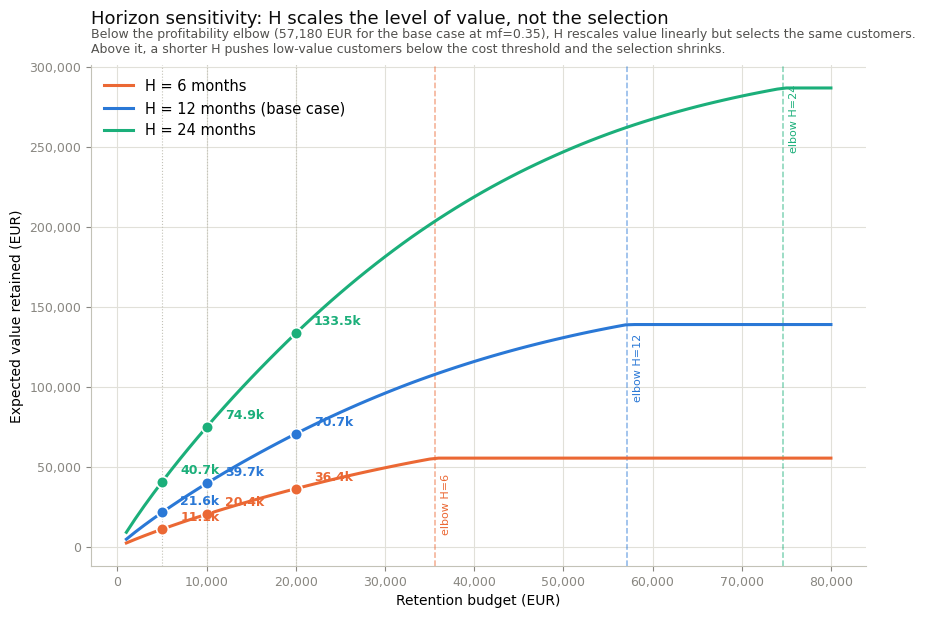

In [23]:
fig, ax = plt.subplots(figsize=(10, 6.5))

for h in HORIZONS:
    d = sweeps_h[h]
    ax.plot(d.budget, d.expected_value, color=H_COLORS[h], linewidth=2.2,
            label=H_LABELS[h], zorder=2)

    marks = d[d.budget.isin(HIGHLIGHTS)]
    ax.scatter(marks.budget, marks.expected_value, s=70, color=H_COLORS[h],
               zorder=3, edgecolor='white', linewidth=1.2)
    for _, r in marks.iterrows():
        ax.annotate(f'{r.expected_value / 1000:,.1f}k',
                    xy=(r.budget, r.expected_value), xytext=(13, 6),
                    textcoords='offset points', fontsize=9,
                    color=H_COLORS[h], fontweight='bold')

    if elbows[h] <= budgets_h.max():
        ax.axvline(elbows[h], color=H_COLORS[h], linewidth=1.1, linestyle='--',
                   alpha=0.55, zorder=1)
        ax.annotate(f'elbow H={h}', xy=(elbows[h], ax.get_ylim()[1]),
                    xytext=(4, -14), textcoords='offset points', fontsize=8,
                    color=H_COLORS[h], rotation=90, va='top')

for b in HIGHLIGHTS:
    ax.axvline(b, color='#c3c2b7', linewidth=0.8, linestyle=':', zorder=1)

style_money_axes(ax, 'Expected value retained (EUR)')
ax.set_title('Horizon sensitivity: H scales the level of value, not the selection',
             fontsize=13, loc='left', pad=30, color='#0b0b0b')
ax.text(0, 1.02,
        f'Below the profitability elbow ({elbows[12]:,.0f} EUR for the base case at '
        f'mf={MF}), H rescales value linearly but selects the same customers.\n'
        'Above it, a shorter H pushes low-value customers below the cost threshold '
        'and the selection shrinks.',
        transform=ax.transAxes, fontsize=9, color='#52514e', va='bottom')
ax.legend(loc='upper left', frameon=False, fontsize=10.5)

fig.savefig(FIGURES_PATH + 'horizon_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## C) Interaction with heterogeneous cost — reasoned, not recomputed

Under channel costs the elbow moves, and it moves per segment rather than
globally: an expensive month-to-month contact needs roughly twice the value to
clear its own 40 EUR threshold, while a two-year contact clears 3 EUR almost
regardless of `H`. Shortening `H` therefore does not shift one elbow, it shifts
three, and the cheap segment survives the cut long after the expensive one stops
being worth it.

None of that reaches the operating range. At 5k/10k/20k the budget is what binds,
not the profitability filter — the same conclusion S3 reached from the other
side, where H=6 left 3,390 profitable customers at mf=1.0 (2,859 under the mf=0.35 used here) competing for 500 slots. Within
the range these figures are quoted at, the selection invariance holds under both
cost regimes; the caveat is about extrapolating to budgets several times larger.

---

## Verification — figures and tables now quote the same margin factor

The figures used to be drawn at `mf=1.0` while the CFO panels were computed at
`mf=0.35`, so a reader comparing a chart against a table saw two different euro
scales. Both now run at `MF`, and the sweep behind Figure 2 must reproduce the
Panel 2 numbers to the cent.

In [24]:
check = (
    df_het[df_het.budget == 10000]
    .set_index('strategy')['expected_value']
    .rename('from_figure_sweep')
    .to_frame()
)
check['from_cfo_panel'] = [
    panel_channel.loc[('10,000', LABELS_HET[k]), 'value_retained']
    for k in check.index
]
check['difference'] = check.from_figure_sweep - check.from_cfo_panel
check.index = [LABELS_HET[k] for k in check.index]

print(f'Budget 10,000 EUR, channel cost, margin factor {MF}\n')
print(check.round(6).to_string())

matches = np.allclose(check.from_figure_sweep, check.from_cfo_panel, atol=1e-6)
assert matches, 'figures and CFO panels disagree -- margin factors are out of step'
print(f'\nFigures and CFO panels agree to the cent: {matches}')

Budget 10,000 EUR, channel cost, margin factor 0.35

                    from_figure_sweep  from_cfo_panel  difference
At random                 8955.812999     8955.812999         0.0
By churn risk            20139.085538    20139.085538         0.0
By risk × value          21554.913153    21554.913153         0.0
Optimal allocation       24320.939660    24320.939660         0.0

Figures and CFO panels agree to the cent: True
